# 12_Industry_Analytics

Aggregates skill intelligence by industry sector.

### Industries
`AI/ML`, `Data Science`, `Software Engineering`, `Cloud & DevOps`,
`Cybersecurity`, `Data Engineering`, `Data Analytics`, `Systems Engineering`

### Outputs
- `industry_analytics.csv` — per-industry aggregated metrics
- `industry_skill_map.csv` — skill → industry membership


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── load inputs ──────────────────────────────────────────────────────────────
ses      = pd.read_csv('../Generated Datasets/ses_rankings.csv')
history  = pd.read_csv('../Generated Datasets/skill_demand_history_clean.csv')
forecasts = pd.read_csv('../Generated Datasets/forecast_results.csv')

for df in [ses, history, forecasts]:
    df['skill'] = df['skill'].str.lower().str.strip()

print("SES shape      :", ses.shape)
print("History shape  :", history.shape)
print("Forecasts shape:", forecasts.shape)


SES shape      : (114, 23)
History shape  : (2304, 4)
Forecasts shape: (114, 12)


In [3]:
# ── industry → skill mapping ──────────────────────────────────────────────────
# sub_category already maps cleanly to industries; we also add cross-industry
# skills (e.g., Python belongs to AI/ML AND Data Science AND Software Eng.)

INDUSTRY_SKILLS = {
    'AI/ML': [
        'machine learning', 'deep learning', 'artificial intelligence',
        'natural language processing', 'computer vision', 'pytorch', 'tensorflow',
        'keras', 'scikit-learn', 'llm', 'langchain', 'rag', 'hugging face',
        'reinforcement learning', 'mlops', 'xgboost', 'lightgbm',
    ],
    'Data Science': [
        'python', 'r', 'statistics', 'statistical analysis', 'data science',
        'pandas', 'numpy', 'jupyter', 'data visualization', 'tableau', 'power bi',
        'machine learning', 'scikit-learn', 'xgboost', 'feature engineering',
        'a/b testing', 'hypothesis testing', 'matplotlib', 'seaborn',
    ],
    'Software Engineering': [
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'golang',
        'rust', 'kotlin', 'swift', 'react', 'angular', 'node.js', 'django',
        'fastapi', 'flask', 'spring', 'microservices', 'system design',
        'agile', 'git', 'software development', 'software engineering',
        'unit testing', 'agile methodologies', 'objectoriented programming',
    ],
    'Cloud & DevOps': [
        'aws', 'azure', 'gcp', 'google cloud', 'microsoft azure', 'cloud computing',
        'docker', 'kubernetes', 'terraform', 'ansible', 'jenkins', 'ci/cd',
        'devops', 'gitlab', 'github', 'azure devops', 'pulumi',
        'cloud security', 'linux', 'bash/shell (all shells)',
    ],
    'Data Engineering': [
        'sql', 'postgresql', 'mysql', 'nosql', 'mongodb', 'cassandra', 'redis',
        'apache spark', 'apache kafka', 'hadoop', 'snowflake', 'etl',
        'data engineering', 'data pipelines', 'data architecture', 'data modeling',
        'dbt', 'airflow', 'data governance', 'elasticsearch', 'dynamodb',
    ],
    'Data Analytics': [
        'sql', 'excel', 'power bi', 'tableau', 'data analysis', 'data analytics',
        'python', 'r', 'business intelligence', 'data visualization',
        'statistics', 'microsoft excel', 'looker', 'qlik',
    ],
    'Cybersecurity': [
        'cybersecurity', 'cyber security', 'information security', 'network security',
        'cloud security', 'penetration testing', 'ethical hacking',
        'siem', 'soc', 'identity and access management',
    ],
    'Systems Engineering': [
        'electrical engineering', 'mechanical engineering', 'systems engineering',
        'computer engineering', 'embedded systems', 'robotics', 'plc programming',
        'electronics', 'matlab', 'autocad', 'vhdl', 'fpga',
    ],
}

# build long-form skill → industry map
rows = []
for industry, skill_list in INDUSTRY_SKILLS.items():
    for skill in skill_list:
        rows.append({'industry': industry, 'skill': skill})

skill_map = pd.DataFrame(rows)
print("Industry-skill map:", skill_map.shape)
print(skill_map['industry'].value_counts())


Industry-skill map: (139, 2)
industry
Software Engineering    26
Data Engineering        21
Cloud & DevOps          20
Data Science            19
AI/ML                   17
Data Analytics          14
Systems Engineering     12
Cybersecurity           10
Name: count, dtype: int64


In [4]:
# ── join SES + forecasts into skill_map ──────────────────────────────────────
skill_map = skill_map.merge(ses, on='skill', how='left')
skill_map = skill_map.merge(
    forecasts[['skill','forecast_1y','forecast_2y','forecast_3y','forecast_trend']],
    on='skill', how='left'
)

# flag whether this skill actually exists in our SES rankings
skill_map['in_ses'] = skill_map['ses_score'].notna().astype(int)

print(f"Skills found in SES: {skill_map['in_ses'].sum()} / {len(skill_map)}")
skill_map.head()


Skills found in SES: 91 / 139


,industry,skill,ses_rank,sub_category,ses_score,ses_tier,feature_score,forecast_intelligence,cluster_score,archetype,...,forecast_3y_x,forecast_method,forecast_trend_x,confidence,history_length,forecast_1y_y,forecast_2y_y,forecast_3y_y,forecast_trend_y,in_ses
0,AI/ML,machine learning,16.0,AI_ML,0.375987,Safe,0.482504,0.165671,0.5,Stable,...,33117.1790,Holt,Growing,0.85,11.0,29392.5242,31268.6515,33117.1790,Growing,1
1,AI/ML,deep learning,18.0,AI_ML,0.372985,Safe,0.444624,0.200386,0.5,Stable,...,12187.7352,ExponentialSmoothing,Growing,0.65,9.0,10808.6990,11498.2171,12187.7352,Growing,1
2,AI/ML,artificial intelligence,76.0,AI_ML,0.311539,Safe,0.378910,0.099928,0.5,Stable,...,9054.9610,Holt,Stable,0.85,10.0,8278.3062,8679.3807,9054.9610,Stable,1
3,AI/ML,natural language processing,33.0,AI_ML,0.354731,Safe,0.454143,0.137354,0.5,Stable,...,22729.2289,Holt,Growing,0.85,10.0,20326.6557,21543.9217,22729.2289,Growing,1
4,AI/ML,computer vision,25.0,AI_ML,0.362742,Safe,0.429122,0.188837,0.5,Stable,...,6689.2795,ExponentialSmoothing,Growing,0.65,9.0,5920.9769,6305.1282,6689.2795,Growing,1


In [5]:
skill_map.columns.tolist()

['industry',
 'skill',
 'ses_rank',
 'sub_category',
 'ses_score',
 'ses_tier',
 'feature_score',
 'forecast_intelligence',
 'cluster_score',
 'archetype',
 'cluster',
 'linkedin_demand',
 'salary_premium',
 'current_usage',
 'future_interest',
 'global_adoption_score',
 'growth_rate',
 'forecast_1y_x',
 'forecast_2y_x',
 'forecast_3y_x',
 'forecast_method',
 'forecast_trend_x',
 'confidence',
 'history_length',
 'forecast_1y_y',
 'forecast_2y_y',
 'forecast_3y_y',
 'forecast_trend_y',
 'in_ses']

In [6]:
skill_map = skill_map.drop(
    columns=[
        'forecast_1y_y',
        'forecast_2y_y',
        'forecast_3y_y',
        'forecast_trend_y'
    ]
)

skill_map = skill_map.rename(columns={
    'forecast_1y_x':'forecast_1y',
    'forecast_2y_x':'forecast_2y',
    'forecast_3y_x':'forecast_3y',
    'forecast_trend_x':'forecast_trend'
})

In [7]:
# ── aggregate by industry ────────────────────────────────────────────────────
def safe_mean(s):
    return s.dropna().mean() if len(s.dropna()) else np.nan

industry_agg = []

for industry, grp in skill_map.groupby('industry'):
    matched = grp[grp['in_ses'] == 1]

    if len(matched) == 0:
        continue

    # tier distribution
    tier_counts = matched['ses_tier'].value_counts().to_dict()

    # forecast YoY growth (1y -> 3y)
    f1 = matched['forecast_1y'].dropna()
    f3 = matched['forecast_3y'].dropna()
    if len(f1) > 0 and len(f3) > 0:
        avg_growth_3y = ((f3.mean() - f1.mean()) / max(f1.mean(), 1)) * 100
    else:
        avg_growth_3y = np.nan

    # demand trend: % of skills growing vs declining
    trend_counts = matched['forecast_trend'].value_counts()
    pct_growing  = (trend_counts.get('Growing', 0) + trend_counts.get('Explosive', 0)) / len(matched) * 100
    pct_declining = trend_counts.get('Declining', 0) / len(matched) * 100

    # historical peak demand
    hist_sub = history[history['skill'].isin(matched['skill'])]
    peak_demand    = hist_sub['demand'].max() if len(hist_sub) else np.nan
    current_demand = hist_sub[hist_sub['year'] == history['year'].max()]['demand'].mean()

    industry_agg.append({
        'industry'              : industry,
        'skill_count'           : len(matched),
        'avg_ses_score'         : round(safe_mean(matched['ses_score']), 4),
        'avg_linkedin_demand'   : round(safe_mean(matched['linkedin_demand']), 4),
        'avg_salary_premium'    : round(safe_mean(matched['salary_premium']), 4),
        'avg_growth_rate'       : round(safe_mean(matched['growth_rate']), 4),
        'avg_future_interest'   : round(safe_mean(matched['future_interest']), 4),
        'avg_global_adoption'   : round(safe_mean(matched['global_adoption_score']), 4),
        'avg_forecast_1y'       : round(safe_mean(matched['forecast_1y']), 2),
        'avg_forecast_3y'       : round(safe_mean(matched['forecast_3y']), 2),
        'forecast_growth_3y_pct': round(avg_growth_3y, 2) if not np.isnan(avg_growth_3y) else None,
        'pct_skills_growing'    : round(pct_growing, 1),
        'pct_skills_declining'  : round(pct_declining, 1),
        'peak_demand'           : int(peak_demand) if not np.isnan(peak_demand) else None,
        'current_demand'        : round(current_demand, 0) if not np.isnan(current_demand) else None,
        'top_ses_tier'          : matched['ses_tier'].mode()[0] if len(matched) else None,
        'very_safe_count'       : tier_counts.get('Very Safe', 0),
        'safe_count'            : tier_counts.get('Safe', 0),
        'moderate_count'        : tier_counts.get('Moderate', 0),
        'risky_count'           : tier_counts.get('Risky', 0),
        'extinction_risk_count' : tier_counts.get('Extinction Risk', 0),
    })

industry_df = pd.DataFrame(industry_agg).sort_values('avg_ses_score', ascending=False)
print(industry_df[['industry','skill_count','avg_ses_score','forecast_growth_3y_pct','pct_skills_growing']].to_string(index=False))


            industry  skill_count  avg_ses_score  forecast_growth_3y_pct  pct_skills_growing
      Data Analytics           11         0.4227                    6.00                27.3
Software Engineering           19         0.3842                    6.72                47.4
        Data Science            9         0.3787                    5.92                66.7
               AI/ML            7         0.3533                   15.19                71.4
       Cybersecurity            6         0.3339                   10.47                66.7
    Data Engineering           13         0.3314                    7.83                38.5
      Cloud & DevOps           17         0.3233                    9.49                64.7
 Systems Engineering            9         0.3001                   10.58                44.4


In [8]:
# ── top skills per industry ───────────────────────────────────────────────────
top_skills_per_industry = {}

for industry, grp in skill_map.groupby('industry'):
    matched = grp[grp['in_ses'] == 1].sort_values('ses_score', ascending=False)
    top_skills_per_industry[industry] = matched['skill'].head(10).tolist()
    print(f"\n{industry} — Top 10 skills:")
    print(matched[['skill','ses_score','ses_tier','forecast_trend']].head(10).to_string(index=False))



AI/ML — Top 10 skills:
                      skill  ses_score ses_tier forecast_trend
           machine learning   0.375987     Safe        Growing
              deep learning   0.372985     Safe        Growing
                 tensorflow   0.369537     Safe        Growing
            computer vision   0.362742     Safe        Growing
natural language processing   0.354731     Safe        Growing
                    pytorch   0.325448     Safe         Stable
    artificial intelligence   0.311539     Safe         Stable

Cloud & DevOps — Top 10 skills:
         skill  ses_score ses_tier forecast_trend
        docker   0.570093     Safe         Stable
           aws   0.476512     Safe         Stable
    kubernetes   0.365308     Safe        Growing
         azure   0.364026     Safe        Growing
        github   0.359217     Safe         Stable
     terraform   0.357901     Safe      Declining
cloud security   0.339118     Safe        Growing
           gcp   0.305938     Safe     

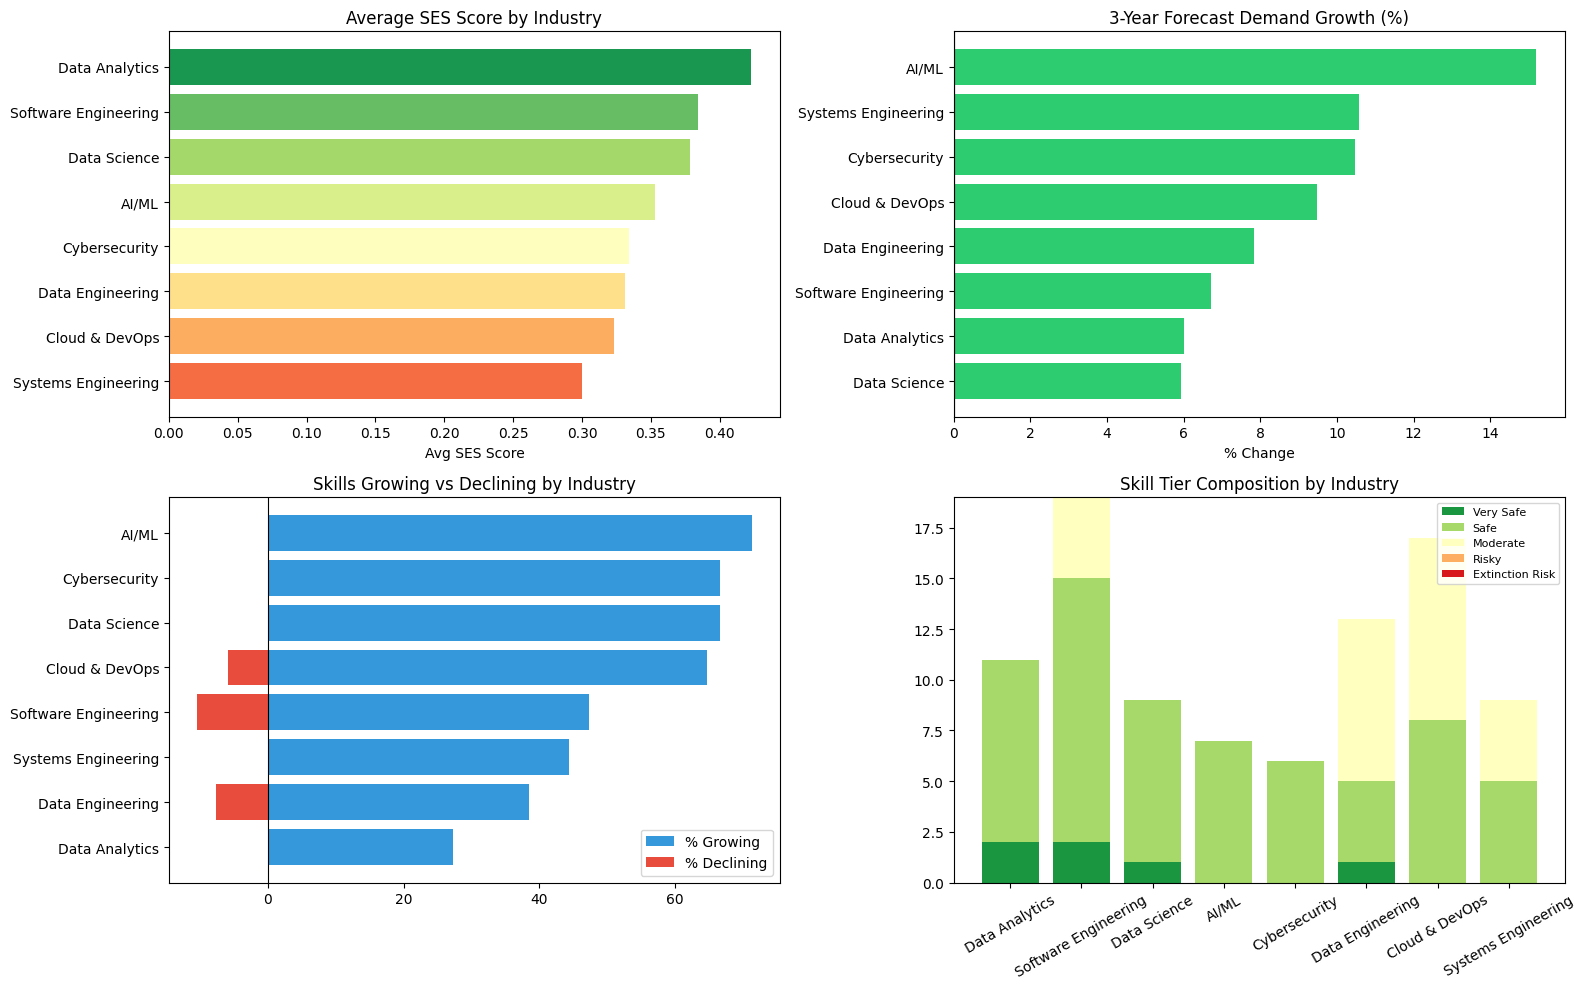

In [9]:
# ── visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Average SES by industry
ind_sorted = industry_df.sort_values('avg_ses_score', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(ind_sorted)))
axes[0,0].barh(ind_sorted['industry'], ind_sorted['avg_ses_score'], color=colors)
axes[0,0].set_title('Average SES Score by Industry')
axes[0,0].set_xlabel('Avg SES Score')

# 2. 3-year forecast growth
ind_growth = industry_df.dropna(subset=['forecast_growth_3y_pct']).sort_values('forecast_growth_3y_pct')
c2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in ind_growth['forecast_growth_3y_pct']]
axes[0,1].barh(ind_growth['industry'], ind_growth['forecast_growth_3y_pct'], color=c2)
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_title('3-Year Forecast Demand Growth (%)')
axes[0,1].set_xlabel('% Change')

# 3. Skills growing vs declining
ind_trend = industry_df.sort_values('pct_skills_growing', ascending=True)
axes[1,0].barh(ind_trend['industry'], ind_trend['pct_skills_growing'],
               color='#3498db', label='% Growing')
axes[1,0].barh(ind_trend['industry'], -ind_trend['pct_skills_declining'],
               color='#e74c3c', label='% Declining')
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Skills Growing vs Declining by Industry')
axes[1,0].legend()

# 4. Tier stacked bar
tier_cols = ['very_safe_count','safe_count','moderate_count','risky_count','extinction_risk_count']
tier_labels = ['Very Safe','Safe','Moderate','Risky','Extinction Risk']
tier_colors = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']
bottom = np.zeros(len(industry_df))
for col, lbl, clr in zip(tier_cols, tier_labels, tier_colors):
    vals = industry_df[col].fillna(0).values
    axes[1,1].bar(industry_df['industry'], vals, bottom=bottom, label=lbl, color=clr)
    bottom += vals
axes[1,1].set_title('Skill Tier Composition by Industry')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../Generated Datasets/industry_analytics.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:
# Archetype distribution by industry

archetype_summary = []

for industry, grp in skill_map.groupby('industry'):

    matched = grp[grp['in_ses'] == 1]

    if len(matched) == 0:
        continue

    counts = matched['archetype'].value_counts()

    total = len(matched)

    archetype_summary.append({
        'industry': industry,

        'future_proof_count': counts.get('Future-Proof', 0),
        'growing_count': counts.get('Growing', 0),
        'stable_count': counts.get('Stable', 0),
        'high_risk_count': counts.get('High-Risk', 0),

        'future_proof_pct': round(
            counts.get('Future-Proof', 0) / total * 100, 1
        ),

        'growing_pct': round(
            counts.get('Growing', 0) / total * 100, 1
        ),

        'stable_pct': round(
            counts.get('Stable', 0) / total * 100, 1
        ),

        'high_risk_pct': round(
            counts.get('High-Risk', 0) / total * 100, 1
        )
    })

archetype_df = pd.DataFrame(archetype_summary)

print("\nArchetype Distribution By Industry")
display(
    archetype_df.sort_values(
        'future_proof_pct',
        ascending=False
    )
)


Archetype Distribution By Industry


,industry,future_proof_count,growing_count,stable_count,high_risk_count,future_proof_pct,growing_pct,stable_pct,high_risk_pct
3,Data Analytics,3,8,0,0,27.3,72.7,0.0,0.0
6,Software Engineering,3,7,0,9,15.8,36.8,0.0,47.4
4,Data Engineering,2,1,0,10,15.4,7.7,0.0,76.9
5,Data Science,1,6,2,0,11.1,66.7,22.2,0.0
1,Cloud & DevOps,1,2,2,11,5.9,11.8,11.8,64.7
0,AI/ML,0,0,6,0,0.0,0.0,85.7,0.0
2,Cybersecurity,0,6,0,0,0.0,100.0,0.0,0.0
7,Systems Engineering,0,8,0,1,0.0,88.9,0.0,11.1


In [12]:
industry_df = industry_df.merge(
    archetype_df,
    on='industry',
    how='left'
)

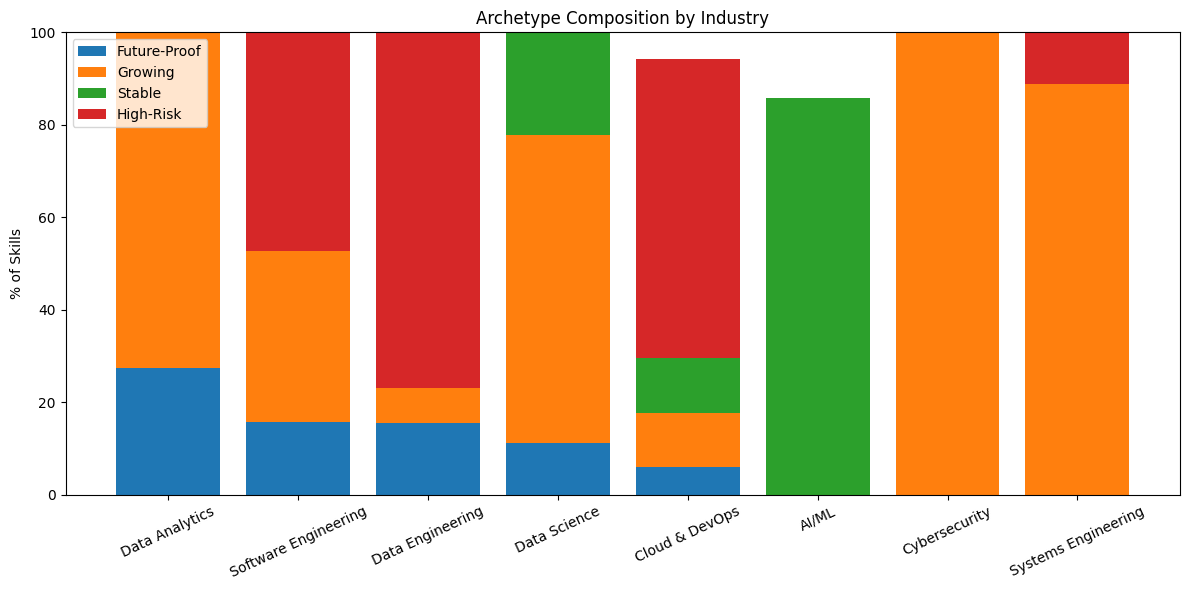

In [13]:
# Archetype composition by industry

plot_df = industry_df.sort_values(
    'future_proof_pct',
    ascending=False
)

fig, ax = plt.subplots(figsize=(12,6))

bottom = np.zeros(len(plot_df))

cols = [
    'future_proof_pct',
    'growing_pct',
    'stable_pct',
    'high_risk_pct'
]

labels = [
    'Future-Proof',
    'Growing',
    'Stable',
    'High-Risk'
]

for col, lbl in zip(cols, labels):

    ax.bar(
        plot_df['industry'],
        plot_df[col],
        bottom=bottom,
        label=lbl
    )

    bottom += plot_df[col].values

ax.set_title('Archetype Composition by Industry')
ax.set_ylabel('% of Skills')
ax.legend()

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [14]:
for industry in archetype_df['industry']:
    print('\n', industry)

    display(
        skill_map[
            (skill_map['industry']==industry)
            & (skill_map['in_ses']==1)
        ][['skill','archetype','ses_score']]
        .sort_values('ses_score', ascending=False)
    )


 AI/ML


,skill,archetype,ses_score
0,machine learning,Stable,0.375987
1,deep learning,Stable,0.372985
6,tensorflow,Stable,0.369537
4,computer vision,Stable,0.362742
3,natural language processing,Stable,0.354731
5,pytorch,NaN,0.325448
2,artificial intelligence,Stable,0.311539



 Cloud & DevOps


,skill,archetype,ses_score
68,docker,Future-Proof,0.570093
62,aws,High-Risk,0.476512
69,kubernetes,Stable,0.365308
63,azure,NaN,0.364026
76,github,Stable,0.359217
70,terraform,Growing,0.357901
79,cloud security,Growing,0.339118
64,gcp,High-Risk,0.305938
80,linux,High-Risk,0.281741
74,devops,High-Risk,0.281233



 Cybersecurity


...

,skill,archetype,ses_score
17,python,Future-Proof,0.720562
28,machine learning,Stable,0.375987
27,power bi,Growing,0.339839
25,data visualization,Growing,0.336435
20,statistical analysis,Growing,0.331152
19,statistics,Growing,0.327350
32,a/b testing,Growing,0.326707
26,tableau,Growing,0.325272
21,data science,Stable,0.324929



 Software Engineering


,skill,archetype,ses_score
38,javascript,Future-Proof,0.767596
36,python,Future-Proof,0.720562
39,typescript,Future-Proof,0.548743
46,react,High-Risk,0.393296
58,software engineering,Growing,0.385506
37,java,High-Risk,0.383787
53,microservices,Growing,0.373920
57,software development,Growing,0.357165
55,agile,Growing,0.338827
59,unit testing,Growing,0.338734



 Systems Engineering


,skill,archetype,ses_score
131,embedded systems,Growing,0.327384
129,systems engineering,Growing,0.325531
130,computer engineering,Growing,0.324381
127,electrical engineering,Growing,0.323331
128,mechanical engineering,Growing,0.320664
132,robotics,Growing,0.297964
135,matlab,Growing,0.289249
134,electronics,Growing,0.288586
133,plc programming,High-Risk,0.204132


In [11]:
# ── save outputs ─────────────────────────────────────────────────────────────
industry_df.to_csv('../Generated Datasets/industry_analytics.csv', index=False)
skill_map[['industry','skill','ses_score','ses_tier','archetype',
           'forecast_1y','forecast_3y','forecast_trend']].to_csv(
    '../Generated Datasets/industry_skill_map.csv', index=False
)

print("Saved industry_analytics.csv")
print("Saved industry_skill_map.csv")
print("\nIndustry analytics summary:")
print(industry_df[['industry','skill_count','avg_ses_score','top_ses_tier']].to_string(index=False))


Saved industry_analytics.csv
Saved industry_skill_map.csv

Industry analytics summary:
            industry  skill_count  avg_ses_score top_ses_tier
      Data Analytics           11         0.4227         Safe
Software Engineering           19         0.3842         Safe
        Data Science            9         0.3787         Safe
               AI/ML            7         0.3533         Safe
       Cybersecurity            6         0.3339         Safe
    Data Engineering           13         0.3314     Moderate
      Cloud & DevOps           17         0.3233     Moderate
 Systems Engineering            9         0.3001         Safe
